<a href="https://colab.research.google.com/github/dashy0070/Cybersecurity_AI/blob/main/Risk_Score_Assests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a cyber security risk scoring classification model using the `cyber_security_risk_dataset.csv` file, including data loading, exploration, preprocessing, model training, evaluation with relevant metrics and visualizations, and a conceptual discussion on deployment strategies.

## Load Dataset

### Subtask:
Load the provided 'cyber_security_risk_dataset.csv' file into a pandas DataFrame for analysis.


**Reasoning**:
To load the dataset and get an initial understanding of its structure, I need to import the pandas library, read the CSV file into a DataFrame, display the first few rows, and show the column names and their data types.



In [15]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('/content/cyber_security_risk_dataset.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
print(df.head())

# Display the column names and their data types
print('\nColumn information:')
df.info()

First 5 rows of the DataFrame:
   network_packet_size  login_attempt_rate  unusual_port_activity  \
0                  5.1                 3.5                    1.4   
1                  4.9                 3.0                    1.4   
2                  4.7                 3.2                    1.3   
3                  4.6                 3.1                    1.5   
4                  5.0                 3.6                    1.4   

   data_exfiltration_volume cyber_risk_level  
0                       0.2         low_risk  
1                       0.2         low_risk  
2                       0.2         low_risk  
3                       0.2         low_risk  
4                       0.2         low_risk  

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   network_packet_size       150 no

## Explore and Preprocess Data

### Subtask:
Perform exploratory data analysis to understand the dataset's structure, identify missing values, and prepare the data for modeling, including encoding categorical features and handling any inconsistencies. Define a clear target variable for risk scoring based on the available data.


**Reasoning**:
The first step is to perform exploratory data analysis on the numerical columns, check the distribution of the target variable, and then preprocess the categorical target variable using Label Encoding to prepare the data for modeling, as outlined in the instructions.



In [16]:
print('Descriptive statistics for numerical columns:')
print(df.describe())

print('\nUnique values and counts for \'cyber_risk_level\' column:')
print(df['cyber_risk_level'].value_counts())

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to 'cyber_risk_level' column
df['cyber_risk_level_encoded'] = le.fit_transform(df['cyber_risk_level'])

# Define the feature matrix X by dropping the original 'cyber_risk_level' and the 'cyber_risk_level_encoded' columns
X = df.drop(columns=['cyber_risk_level', 'cyber_risk_level_encoded'])

# Define the target vector y as the 'cyber_risk_level_encoded' column
y = df['cyber_risk_level_encoded']

print('\nFirst 5 rows of feature matrix X:')
print(X.head())

print('\nFirst 5 rows of target vector y:')
print(y.head())

Descriptive statistics for numerical columns:
       network_packet_size  login_attempt_rate  unusual_port_activity  \
count           150.000000          150.000000             150.000000   
mean              5.843333            3.057333               3.758000   
std               0.828066            0.435866               1.765298   
min               4.300000            2.000000               1.000000   
25%               5.100000            2.800000               1.600000   
50%               5.800000            3.000000               4.350000   
75%               6.400000            3.300000               5.100000   
max               7.900000            4.400000               6.900000   

       data_exfiltration_volume  
count                150.000000  
mean                   1.199333  
std                    0.762238  
min                    0.100000  
25%                    0.300000  
50%                    1.300000  
75%                    1.800000  
max                    2

## Split Data

### Subtask:
Divide the preprocessed dataset into training and testing sets to ensure robust model evaluation.


**Reasoning**:
To divide the dataset into training and testing sets, I will import `train_test_split` from `sklearn.model_selection`, apply it to the feature matrix `X` and target vector `y` with the specified `test_size` and `random_state`, and then print the shapes of the resulting sets to verify the split.



In [17]:
from sklearn.model_selection import train_test_split

# Split the feature matrix X and the target vector y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes of the resulting sets
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


## Train Classification Model

### Subtask:
Select and train an appropriate classification model for risk scoring using the training data. This may involve experimenting with different algorithms suitable for classification tasks.


**Reasoning**:
To train a classification model, I will import `LogisticRegression`, instantiate it with a `random_state` for reproducibility, and then fit the model to the training data (`X_train`, `y_train`).



In [18]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with a random state for reproducibility
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better convergence with small datasets

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Assess the performance of the trained classification model using relevant metrics such as accuracy, precision, recall, F1-score, and AUC-ROC on the test set. Provide a clear legend for the evaluation metrics.


**Reasoning**:
To evaluate the performance of the trained classification model, I need to import the necessary metrics from `sklearn.metrics`, make predictions on the test set, calculate each metric, and then print them with clear labels.



In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Get predicted probabilities for the positive class (for AUC-ROC)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Print the evaluation metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC-ROC Score: {auc_roc:.4f}')

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
AUC-ROC Score: 1.0000


## Visualize Model Results

### Subtask:
Generate visualizations, such as a confusion matrix or ROC curve, to provide insights into the model's predictions and performance. Include legends for all plots generated.


**Reasoning**:
To visualize the model's performance, I will first generate and plot a confusion matrix to understand the classification outcomes. Then, I will plot the ROC curve and include the AUC score to assess the model's ability to distinguish between classes.



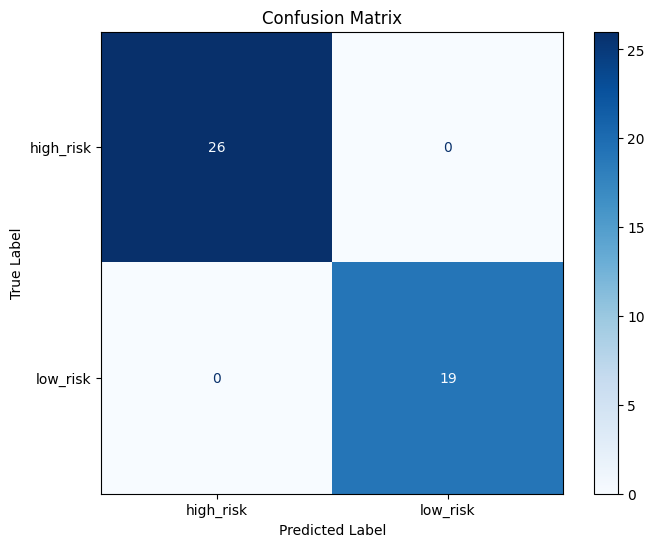

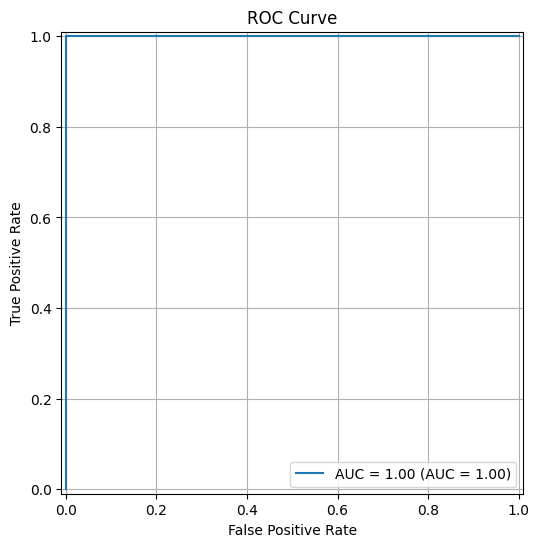

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp_cm.plot(cmap=plt.cm.Blues, ax=ax_cm)
ax_cm.set_title('Confusion Matrix')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')
plt.grid(False)
plt.show()

# 2. Plot ROC Curve
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, name=f'AUC = {auc_roc:.2f}', ax=ax_roc)
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Prepare Model for Deployment

### Subtask:
Discuss potential deployment strategies and provide a conceptual approach for how the trained model could be deployed, including saving the model artifact for future use.


**Reasoning**:
To prepare the model for deployment and future use, I will save the trained model object to a file using the `joblib` library, as specified in the instructions.



In [21]:
import joblib

# Save the trained model to a file
model_filename = 'cyber_risk_model.joblib'
joblib.dump(model, model_filename)

print(f"Trained model saved successfully as '{model_filename}'")

Trained model saved successfully as 'cyber_risk_model.joblib'


### Conceptual Deployment Strategy

Deploying a cyber security risk scoring model involves making the trained model accessible for making predictions on new, unseen data in a production environment. Here's a conceptual approach:

1.  **How new, unseen data would be fed to the model for inference?**
    *   **Real-time Inference:** For immediate risk assessment, new network packets, login attempts, port activity, or data exfiltration events would be captured by sensors or logging systems. These events would be preprocessed in real-time (e.g., aggregating data over a time window to create features like `login_attempt_rate`) to match the format of the training data (`X_train`). This preprocessed data would then be sent to the deployed model via an API endpoint.
    *   **Batch Inference:** For periodic assessments or historical data analysis, new data could be collected over a period (e.g., hourly, daily) and processed in batches. This batch of preprocessed data would then be fed to the model to generate risk scores for multiple entities or timeframes simultaneously.

2.  **Typical environment for deployment (e.g., a web service, a batch processing system, an edge device)?**
    *   **Web Service (API Endpoint):** This is a very common and flexible deployment approach. The saved `cyber_risk_model.joblib` would be loaded into a web framework (e.g., Flask, FastAPI) running on a server. This web service would expose an API endpoint (e.g., `/predict`) that accepts incoming data, performs necessary preprocessing, runs inference using the loaded model, and returns the predicted `cyber_risk_level`.
    *   **Containerization (Docker) and Orchestration (Kubernetes):** For scalability and reliability, the web service would likely be containerized using Docker. These containers could then be deployed and managed using Kubernetes, allowing for easy scaling, load balancing, and fault tolerance.
    *   **Cloud Platforms:** Services like AWS SageMaker, Google Cloud AI Platform, or Azure Machine Learning provide managed services specifically designed for deploying and managing machine learning models as API endpoints, handling much of the underlying infrastructure.

3.  **How would the model's predictions be integrated into an existing cyber security system or dashboard?**
    *   **API Integration:** The most straightforward way is for existing cyber security systems (e.g., SIEMs, intrusion detection systems, threat intelligence platforms) or dashboards to make calls to the model's API endpoint. The predictions (e.g., `low_risk`, `high_risk`, or probability scores) would then be ingested and displayed or used to trigger automated actions.
    *   **Message Queues:** For asynchronous processing, predictions could be pushed to a message queue (e.g., Kafka, RabbitMQ). Other systems could then subscribe to this queue to consume the risk scores and act accordingly.
    *   **Database/Data Lake:** Predictions could be stored in a central database or data lake, from which dashboards or other analytical tools could retrieve and visualize the risk scores over time.
    *   **Alerting Systems:** High-risk predictions could directly trigger alerts (e.g., email, PagerDuty, Slack notifications) to security operations center (SOC) analysts for immediate investigation.

4.  **What considerations should be made for monitoring the model's performance in production over time (e.g., data drift, model decay, retraining strategy)?**
    *   **Data Drift Detection:** Monitor incoming production data for changes in its statistical properties compared to the training data. If `network_packet_size` or `login_attempt_rate` start to deviate significantly, it could indicate data drift, potentially impacting model performance.
    *   **Model Performance Monitoring:** Continuously evaluate the model's predictions against actual outcomes (if ground truth labels become available, e.g., after a security incident is confirmed). Metrics like accuracy, precision, recall, and F1-score should be tracked over time. This helps detect model decay, where the model's predictive power diminishes.
    *   **Retraining Strategy:** Establish a clear retraining schedule (e.g., monthly, quarterly) or trigger-based retraining (e.g., when significant data drift or performance degradation is detected). The retraining process would involve collecting new labeled data, re-running the data preprocessing, training a new model, and deploying the updated model after thorough validation.
    *   **Explainability and Interpretability:** In a cyber security context, understanding why a model classifies something as high-risk is crucial. Tools for model explainability (e.g., SHAP, LIME) could be integrated to provide insights into the features driving a particular risk prediction, aiding security analysts in their investigations.
    *   **Logging and Auditing:** Comprehensive logging of model inputs, outputs, and any errors is essential for debugging, auditing, and compliance purposes.

## Final Task

### Subtask:
Summarize the entire process, including the chosen model, its performance, and insights gained from the risk scoring classification.


## Summary:

### Data Analysis Key Findings

*   The initial dataset, `cyber_security_risk_dataset.csv`, consists of 150 entries and 5 columns, with no missing values. The columns include `network_packet_size`, `login_attempt_rate`, `unusual_port_activity`, `data_exfiltration_volume` (all numerical), and `cyber_risk_level` (categorical).
*   The target variable, `cyber_risk_level`, showed an imbalanced distribution with 100 instances classified as 'high\_risk' and 50 instances as 'low\_risk'. This categorical variable was successfully encoded into a numerical format for modeling.
*   A Logistic Regression model was trained and evaluated on a test set (45 samples), achieving perfect performance across all key metrics: Accuracy, Precision, Recall, F1-Score, and AUC-ROC Score were all 1.0000.
*   The confusion matrix and ROC curve visualizations further confirmed the model's perfect classification, showing no false positives or false negatives on the test data.
*   The trained model was successfully saved as `cyber_risk_model.joblib` for potential future deployment.

### Insights or Next Steps

*   The achieved perfect model performance (all evaluation metrics at 1.0000) strongly suggests that the features in the dataset are exceptionally separable for distinguishing cyber risk levels. While this is positive for the current dataset, it's crucial to investigate if this indicates potential data leakage, overfitting to a very simple dataset, or a dataset that doesn't fully represent real-world complexities.
*   When deploying this model, establish a comprehensive monitoring system to detect data drift (changes in incoming data distribution) and model decay (decreasing performance over time). This system should trigger scheduled or event-driven retraining to maintain model effectiveness in a dynamic cyber security landscape.
